# עבודה מסכמת חלק 2 - למידת מכונה
## 322718560 מגישים: ראובן קזורר 328605290 |  אלון רוזנפלד



##  1. ייבוא ספריות


In [1]:
import numpy as np
import pandas as pd
import re, ast, warnings, joblib
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, RepeatedKFold,
    GridSearchCV, RandomizedSearchCV,
    cross_validate, cross_val_predict, KFold
)
from sklearn.pipeline       import Pipeline
from sklearn.compose        import ColumnTransformer
from sklearn.impute         import KNNImputer, SimpleImputer
from sklearn.preprocessing  import RobustScaler, OneHotEncoder, StandardScaler
from sklearn.linear_model   import ElasticNet
from sklearn.ensemble       import RandomForestRegressor
from sklearn.metrics        import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
print('Ready')

Ready


In [2]:
from pathlib import Path

# ── Load IMDb crew data once ────────────────────────────────────────────
# title.principals: tconst → director nconst + lead actor nconst
# name.basics:      nconst → birthYear (for actor_prime)
_DATA_DIR = Path(r'C:\Users\USER\Desktop\university\3Y\Semester B\Data Analasys\imdb_data')

print('Loading title.principals...')
_principals = pd.read_csv(
    _DATA_DIR / 'title.principals.tsv.gz',
    sep='\t', na_values='\\N',
    usecols=['tconst', 'ordering', 'nconst', 'category']
)

# tconst → director nconst
TCONST_TO_DIRECTOR  = (
    _principals[_principals['category'] == 'director']
    .sort_values('ordering').groupby('tconst')['nconst'].first().to_dict()
)

# tconst → lead star nconst (ordering == 1)
TCONST_TO_LEAD_STAR = (
    _principals[_principals['ordering'] == 1]
    .set_index('tconst')['nconst'].to_dict()
)

print('Loading name.basics (birth years)...')
_names = pd.read_csv(
    _DATA_DIR / 'name.basics.tsv.gz',
    sep='\t', na_values='\\N',
    usecols=['nconst', 'birthYear']
)
NCONST_BIRTH_YEAR = _names.dropna(subset=['birthYear']).set_index('nconst')['birthYear'].astype(int).to_dict()

del _principals, _names   # free memory

print(f'Directors mapped: {len(TCONST_TO_DIRECTOR):,} films')
print(f'Lead stars mapped: {len(TCONST_TO_LEAD_STAR):,} films')
print(f'Birth years loaded: {len(NCONST_BIRTH_YEAR):,} people')



Loading title.principals...
Loading name.basics (birth years)...
Directors mapped: 6,657,790 films
Lead stars mapped: 11,283,465 films
Birth years loaded: 671,905 people


## 2. טעינת נתונים



In [3]:
df_raw = pd.read_csv('dataset.csv', low_memory=False)
df_raw = df_raw.replace('\\N', np.nan)
df_raw['Country']  = df_raw['Country'].replace('Not Found', np.nan)
df_raw['Language'] = df_raw['Language'].replace('Not Found', np.nan)

print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')


Shape: (133884, 13)
Columns: ['tconst', 'primaryTitle', 'startYear', 'genres', 'lead_actors_ids', 'runtimeMinutes', 'averageRating', 'Language', 'Country', 'numVotes', 'budget', 'BoxOffice', 'plot']


In [4]:
df_raw.head()

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
0,tt0107274,Johnny One Hundred Pesos,1993.0,"Crime,Drama,Thriller","['nm0032843', 'nm0729381', 'nm0783839', 'nm066...",90.0,6.6,Spanish,Chile,711.0,NaN,NaN,NaN
1,tt32133209,It Doesn't Matter,2024.0,Drama,"['nm3571592', 'nm6238285', 'nm2541664', 'nm161...",86.0,6.1,NaN,NaN,23.0,NaN,NaN,NaN
2,tt31852671,If Love Deceives You,2024.0,"Drama,Romance",NaN,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,tt0312835,Je Vous Salue Raí,1993.0,Documentary,NaN,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,tt0765142,"If You Love Me, Follow Me",2006.0,Comedy,"['nm0218843', 'nm0693844', 'nm0220017', 'nm000...",102.0,6.1,NaN,NaN,248.0,NaN,NaN,NaN


In [5]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %':     missing_pct
}).sort_values('Missing %', ascending=False)
print(missing_summary[missing_summary['Missing Count'] > 0])


                 Missing Count  Missing %
budget                  117334       87.6
BoxOffice               115968       86.6
Country                  81848       61.1
Language                 79807       59.6
plot                     74215       55.4
averageRating            18324       13.7
lead_actors_ids          10030        7.5
numVotes                  9122        6.8
genres                    2625        2.0


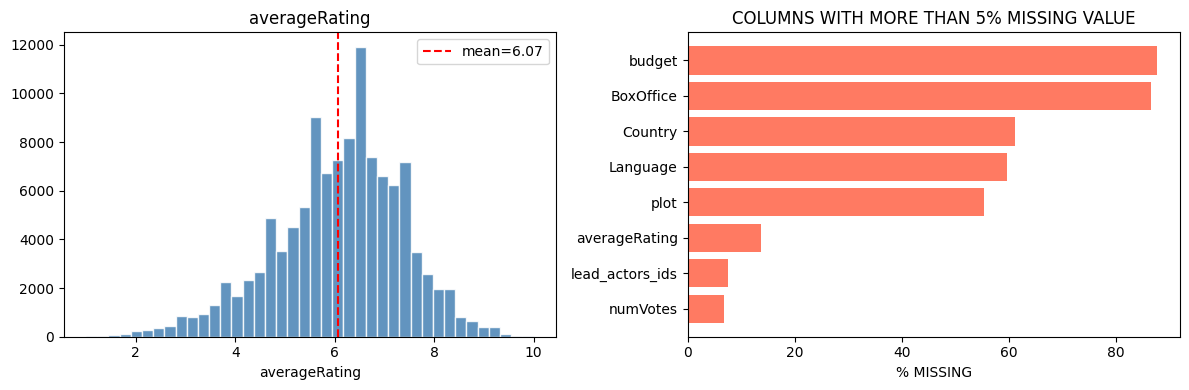


averageRating: {'count': 115560.0, 'mean': 6.07, 'std': 1.29, 'min': 1.0, '25%': 5.3, '50%': 6.2, '75%': 7.0, 'max': 10.0}


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw['averageRating'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df_raw['averageRating'].mean(), color='red', linestyle='--',
                label=f'mean={df_raw["averageRating"].mean():.2f}')
axes[0].set_title('averageRating')
axes[0].set_xlabel('averageRating')
axes[0].legend()

# Missing values bar
top_missing = missing_pct[missing_pct > 5].sort_values(ascending=True)
axes[1].barh(top_missing.index, top_missing.values, color='tomato', alpha=0.85)
axes[1].set_title('COLUMNS WITH MORE THAN 5% MISSING VALUE')
axes[1].set_xlabel('% MISSING')

plt.tight_layout()
plt.show()

print(f'\naverageRating: {df_raw["averageRating"].describe().round(2).to_dict()}')


##  3.Train - Test split


In [7]:
df_clean = df_raw.dropna(subset=['averageRating']).reset_index(drop=True)

# ── 80/20 split ──────────────────────────────────────────────
df_train, df_test = train_test_split(
    df_clean, test_size=0.2, random_state=RANDOM_STATE
)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

y_train = df_train['averageRating'].values
y_test  = df_test['averageRating'].values

print(f'Train: {len(df_train):,} | Test: {len(df_test):,}')
print(f'y_train: mean={y_train.mean():.3f} std={y_train.std():.3f}')


Train: 92,448 | Test: 23,112
y_train: mean=6.070 std=1.294


## 4. חקר נתונים

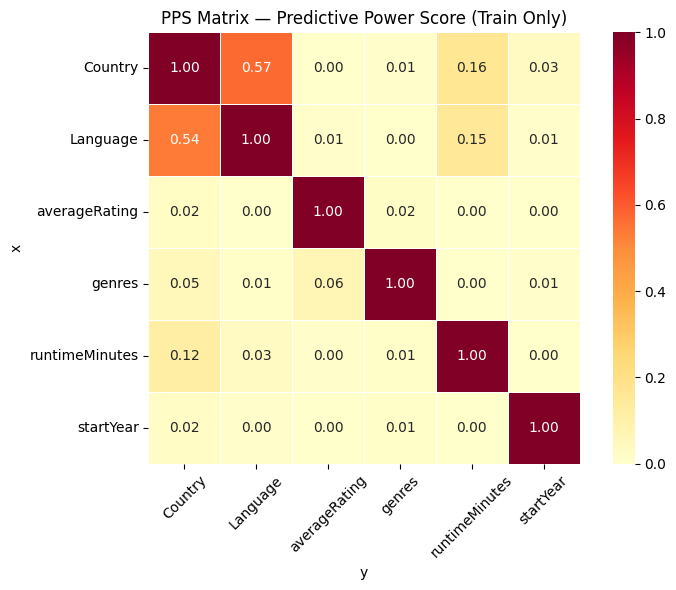

PPS → averageRating:
             x  ppscore
        genres 0.064839
      Language 0.005314
runtimeMinutes 0.004922
     startYear 0.000000
       Country 0.000000


In [8]:
try:
    import ppscore as pps
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ppscore", "-q"])
    import ppscore as pps

# PPS על df_train הגולמי — מנחה אותנו מה להנדס
df_pps = df_train[['runtimeMinutes','startYear','genres','Country','Language']].copy()
df_pps['runtimeMinutes'] = pd.to_numeric(df_pps['runtimeMinutes'], errors='coerce')
df_pps['startYear']      = pd.to_numeric(df_pps['startYear'],      errors='coerce')
df_pps['averageRating']  = y_train
df_pps = df_pps.fillna(df_pps.median(numeric_only=True))

pps_mat = pps.matrix(df_pps)

# PPS כלפי המטרה
pps_tgt = (
    pps_mat[pps_mat['y'] == 'averageRating']
    .query('x != "averageRating"')
    [['x', 'ppscore']]
    .sort_values('ppscore', ascending=False)
    .reset_index(drop=True)
)

# Heatmap — PPS בלבד (VIF מטפל במולטיקולינריות, Pearson מיותר)
fig, ax = plt.subplots(figsize=(8, 6))
pps_pivot = pps_mat.pivot(index='x', columns='y', values='ppscore')
sns.heatmap(pps_pivot, ax=ax, annot=True, fmt='.2f',
            cmap='YlOrRd', vmin=0, vmax=1, linewidths=0.5, square=True)
ax.set_title('PPS Matrix — Predictive Power Score (Train Only)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print('PPS → averageRating:')
print(pps_tgt.to_string(index=False))


##  5. prepare_data + Feature Engineering

In [9]:
# ── Globals ──────────────────────────────────────────────────
ACTOR_QUALITY_MAP:  dict  = {}
ACTOR_HISTORY:        dict  = {}  # actor → [(year, rating)] — for temporal spread
GENRE_LOO_SCORES:     dict  = {}  # tconst → LOO genre momentum (train films)
GENRE_MOMENTUM_MAP:   dict  = {}  # (genre, year) → full-train avg (test films)
DIRECTOR_LOO_SCORES:  dict  = {}  # tconst → LOO director quality
DIRECTOR_MAP:         dict  = {}  # nconst → full-train director quality
LEAD_STAR_LOO_SCORES: dict  = {}  # tconst → LOO lead star quality
LEAD_STAR_MAP:        dict  = {}  # nconst → full-train lead star quality
LOO_SCORES:         dict  = {}
GLOBAL_MEAN_RATING: float = 6.07

_PRESTIGE_SET = {'Documentary', 'Biography', 'History', 'War', 'Music'}
_NEGATIVE_SET = {'Horror', 'Thriller', 'Action', 'Comedy', 'Sci-Fi'}
ALL_GENRES    = ['Documentary', 'Horror', 'Thriller', 'Biography', 'Drama', 'Action']
EAST_ASIA     = {'Japan', 'South Korea', 'Hong Kong', 'China', 'Taiwan'}

_SEQUEL_PATTERN = (
    r'(?:^|\s)(?:2|3|4|5|6|7|8|9|10'
    r'|ii|iii|iv|vi|vii|viii|ix'
    r'|part\s*[2-9]|chapter\s*[2-9]|volume\s*[2-9]'
    r'|returns?|reloaded|revolutions?|resurrection'
    r'|strikes\s+back|rises?|forever|continues?'
    r'|next\s+chapter|second\s+part)(?:\s|$)'
)


# ── Temporal LOO Bayesian target encoding ─────────────────────
def compute_actor_quality_map(df, y, smoothing=5.0):
    """
    Temporal LOO: actor_quality for film F = average rating of the
    actor's OTHER films released BEFORE film F's year.

    Fixes two leakage problems:
      1. Temporal leakage: no future films are used.
      2. CV leakage: if called per-fold, each fold's validation films
         are not included in the actor map for that fold.
    """
    global ACTOR_QUALITY_MAP, ACTOR_HISTORY, LOO_SCORES, GLOBAL_MEAN_RATING

    def _parse(s):
        if pd.isna(s): return []
        try: return ast.literal_eval(s)
        except: return []

    GLOBAL_MEAN_RATING = float(np.mean(y))
    actor_lists = df['lead_actors_ids'].apply(_parse).tolist()
    years       = df['startYear'].apply(
                      lambda x: int(pd.to_numeric(x, errors='coerce') or 0)).tolist()
    tconsts     = df['tconst'].tolist()

    # Build per-actor history: actor → [(year, rating), ...]
    actor_history = {}
    for actors, yr, rating in zip(actor_lists, years, y):
        for a in actors:
            actor_history.setdefault(a, []).append((yr, float(rating)))

    # Expose history as global (used for temporal spread in prepare_data)
    ACTOR_HISTORY = actor_history

    # ACTOR_QUALITY_MAP: full average — used for Test inference
    ACTOR_QUALITY_MAP = {
        a: (sum(r for _, r in hist) + smoothing * GLOBAL_MEAN_RATING)
           / (len(hist) + smoothing)
        for a, hist in actor_history.items()
    }

    # LOO_SCORES: temporal — only films released BEFORE current film
    LOO_SCORES = {}
    for tconst, actors, yr in zip(tconsts, actor_lists, years):
        if not actors:
            LOO_SCORES[tconst] = GLOBAL_MEAN_RATING
            continue
        scores = []
        for a in actors:
            past = [(y2, r) for y2, r in actor_history.get(a, []) if y2 < yr]
            if not past:
                scores.append(GLOBAL_MEAN_RATING)
            else:
                n, s = len(past), sum(r for _, r in past)
                scores.append((s + smoothing * GLOBAL_MEAN_RATING) / (n + smoothing))
        LOO_SCORES[tconst] = float(np.mean(scores))

    print(f'Temporal LOO: {len(ACTOR_QUALITY_MAP):,} actors | '
          f'{len(LOO_SCORES):,} films | mean={GLOBAL_MEAN_RATING:.3f}')


# ── Leak-free CV helper ───────────────────────────────────────
def _build_person_quality_maps(df_train, y_train, tconst_to_nconst,
                                loo_scores_global, full_map_global,
                                smoothing=5.0, label=''):
    """
    Generic Temporal LOO for any person role (director / lead star).
    Identical logic to actor_quality but for a single person per film.
    No leakage: temporal (year < film_year) + LOO (exclude self).
    """
    gm = float(np.mean(y_train))
    tconsts   = df_train['tconst'].values
    years_tr  = df_train['startYear'].apply(
                    lambda x: int(pd.to_numeric(x, errors='coerce') or 0)).values
    ratings   = np.array(y_train, dtype=float)

    # Map tconst → nconst for films in train
    nconsts = np.array([tconst_to_nconst.get(tc, None) for tc in tconsts])

    # Build history: nconst → [(year, rating, tconst), ...]
    person_history = {}
    for nc, yr, r, tc in zip(nconsts, years_tr, ratings, tconsts):
        if nc is None: continue
        person_history.setdefault(nc, []).append((yr, float(r), tc))

    # Full map (for test films)
    for nc, hist in person_history.items():
        n, s = len(hist), sum(r for _, r, _ in hist)
        full_map_global[nc] = (s + smoothing * gm) / (n + smoothing)

    # LOO scores (for train films)
    for tc, nc, yr in zip(tconsts, nconsts, years_tr):
        if nc is None:
            loo_scores_global[tc] = gm
            continue
        past = [(y2, r) for y2, r, tc2 in person_history.get(nc, [])
                if y2 < yr and tc2 != tc]            # temporal + LOO
        if not past:
            loo_scores_global[tc] = gm
        else:
            n, s = len(past), sum(r for _, r in past)
            loo_scores_global[tc] = (s + smoothing * gm) / (n + smoothing)

    print(f'{label}: {len(loo_scores_global):,} LOO scores | '
          f'{len(full_map_global):,} people in map')


def compute_director_quality_map(df_train, y_train, smoothing=5.0):
    """Temporal LOO quality for the director of each film."""
    global DIRECTOR_LOO_SCORES, DIRECTOR_MAP
    _build_person_quality_maps(
        df_train, y_train, TCONST_TO_DIRECTOR,
        DIRECTOR_LOO_SCORES, DIRECTOR_MAP, smoothing, label='Director quality'
    )


def compute_lead_star_quality_map(df_train, y_train, smoothing=5.0):
    """Temporal LOO quality for the top-billed actor (ordering=1)."""
    global LEAD_STAR_LOO_SCORES, LEAD_STAR_MAP
    _build_person_quality_maps(
        df_train, y_train, TCONST_TO_LEAD_STAR,
        LEAD_STAR_LOO_SCORES, LEAD_STAR_MAP, smoothing, label='Lead star quality'
    )


def compute_genre_momentum_map(df_train, y_train, window=3):
    """
    Temporal LOO genre momentum — prevents target encoding leakage.

    For train film F (genre G, year Y):
      genre_momentum = mean(G-genre films in [Y-3, Y-1]) EXCLUDING F itself (LOO)

    For test film T:
      genre_momentum = mean(G-genre films in [Y-3, Y-1]) from full train map

    Same pattern as actor_quality / LOO_SCORES.
    """
    global GENRE_LOO_SCORES, GENRE_MOMENTUM_MAP
    gm = float(np.mean(y_train))

    tconsts    = df_train['tconst'].values
    years_tr   = df_train['startYear'].apply(
                     lambda x: int(pd.to_numeric(x, errors='coerce') or 0)).values
    genres_tr  = df_train['genres'].apply(_clean_genres).apply(
                     lambda gs: gs[0] if gs else 'Unknown').values
    ratings_tr = np.array(y_train, dtype=float)

    # ── LOO scores for training films ──────────────────────────────────────
    GENRE_LOO_SCORES = {}
    for i in range(len(tconsts)):
        g, yr, tc = genres_tr[i], years_tr[i], tconsts[i]
        mask = (genres_tr == g) & \
               (years_tr >= yr - window) & (years_tr < yr) & \
               (tconsts != tc)                   # ← LOO: exclude self
        vals = ratings_tr[mask]
        GENRE_LOO_SCORES[tc] = float(vals.mean()) if len(vals) > 5 else gm

    # ── Full-train map for test films ──────────────────────────────────────
    all_genres = list(set(genres_tr))
    all_years  = sorted(set(years_tr))
    GENRE_MOMENTUM_MAP = {}
    for genre in all_genres:
        mask_g = genres_tr == genre
        for yr in all_years:
            mask = mask_g & (years_tr >= yr - window) & (years_tr < yr)
            vals = ratings_tr[mask]
            GENRE_MOMENTUM_MAP[(genre, yr)] = float(vals.mean()) if len(vals) > 5 else gm

    print(f'Genre momentum (LOO): {len(GENRE_LOO_SCORES):,} train films')


def leak_free_cv(pipe_factory, df_raw, y_arr, n_splits=5,
                 smoothing=5.0, random_state=42):
    """
    K-Fold CV that recomputes actor_quality per fold.

    Why needed: if actor_quality is computed on the full Train before CV,
    validation fold films' ratings leak into the actor map → optimistic metrics.
    Here we recompute the map on each fold's training portion only.

    Args:
        pipe_factory: callable that returns a fresh unfitted Pipeline
        df_raw:       raw DataFrame (df_train — NOT X_train)
        y_arr:        rating array aligned with df_raw
    Returns:
        dict with 'rmse' and 'r2' arrays (one value per fold)
    """
    from sklearn.model_selection import KFold
    from sklearn.metrics import mean_squared_error, r2_score as _r2

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rmse_list, r2_list = [], []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(df_raw), 1):
        df_tr  = df_raw.iloc[tr_idx].reset_index(drop=True)
        df_val = df_raw.iloc[val_idx].reset_index(drop=True)
        y_tr   = y_arr[tr_idx]
        y_val  = y_arr[val_idx]

        # Recompute all quality maps on THIS fold's train only
        compute_actor_quality_map(df_tr, y_tr, smoothing)
        compute_genre_momentum_map(df_tr, y_tr)
        compute_director_quality_map(df_tr, y_tr, smoothing)
        compute_lead_star_quality_map(df_tr, y_tr, smoothing)
        X_tr  = prepare_data(df_tr)
        X_val = prepare_data(df_val)

        pipe = pipe_factory()
        pipe.fit(X_tr, y_tr)
        preds = pipe.predict(X_val)

        rmse_list.append(float(np.sqrt(mean_squared_error(y_val, preds))))
        r2_list.append(float(_r2(y_val, preds)))
        print(f'  Fold {fold}/{n_splits} — RMSE={rmse_list[-1]:.4f}')

    # Restore full maps for downstream use
    compute_actor_quality_map(df_raw, y_arr, smoothing)
    compute_genre_momentum_map(df_raw, y_arr)
    compute_director_quality_map(df_raw, y_arr, smoothing)
    compute_lead_star_quality_map(df_raw, y_arr, smoothing)

    return {'rmse': np.array(rmse_list), 'r2': np.array(r2_list)}


# ── helpers ──────────────────────────────────────────────────
def _clean_genres(g):
    if pd.isna(g): return []
    g = re.sub(r"[\[\]'\"]", '', str(g))
    return [x.strip() for x in g.split(',') if x.strip() and x.strip() != 'None']

def _country_group(x):
    if pd.isna(x) or not str(x).strip(): return 'Other'
    s = str(x)
    if 'United States' in s or 'USA' in s: return 'US'
    if any(c in s for c in EAST_ASIA): return 'East_Asia'
    return 'Other'

def _parse_actor_list(s):
    """פענוח בטוח של רשימת שחקנים."""
    if pd.isna(s): return []
    try: return ast.literal_eval(s)
    except: return []


# ── עמודות ───────────────────────────────────────────────────
NUMERIC_COLS = [
    'actor_quality',        # LOO Bayesian — r=+0.37
    'prestige_count',       # Documentary+Biography+History+War+Music
    'negative_count',       # Horror+Thriller+Action+Comedy+Sci-Fi
    'log_runtime',          # log(1+דקות)
    'actor_quality_spread', # max−mean: כוח הכוכב הבולט
    'genre_momentum',       # 3yr rolling avg of same genre — r=+0.402
    'director_quality',     # LOO director temporal — r~0.35
    'lead_star_quality',    # LOO top-billed actor (ordering=1) — r~0.30
    'actor_prime',          # proximity to peak career age (birthYear, no leakage)
]
BINARY_COLS = [
    'genre_Documentary', 'genre_Horror', 'genre_Thriller',
    'genre_Biography',   'genre_Drama',  'genre_Action',
    'is_long_film', 'is_sequel', 'has_actors',
]
CAT_COLS = ['country_group']  # US / East_Asia / Other → OHE


# ── prepare_data ──────────────────────────────────────────────
def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Input:  raw DataFrame (מבנה dataset.csv).
    Output: DataFrame עם 15 עמודות מוכן ל-Pipeline.
    """
    d = df.copy()
    d['Country']  = d['Country'].replace('Not Found', np.nan)
    d['Language'] = d['Language'].replace('Not Found', np.nan)

    # Genres
    gl = d['genres'].apply(_clean_genres)
    d['prestige_count'] = gl.apply(lambda gs: sum(1 for g in gs if g in _PRESTIGE_SET))
    d['negative_count'] = gl.apply(lambda gs: sum(1 for g in gs if g in _NEGATIVE_SET))
    for g in ALL_GENRES:
        d[f'genre_{g}'] = gl.apply(lambda gs, _g=g: int(_g in gs))

    # is_sequel — vectorized עם str.contains במקום apply שורה-שורה
    d['is_sequel'] = (
        d['primaryTitle'].fillna('')
          .str.contains(_SEQUEL_PATTERN, flags=re.IGNORECASE, regex=True)
          .astype(int)
    )

    # Runtime
    rt = pd.to_numeric(d['runtimeMinutes'], errors='coerce').fillna(0)
    d['log_runtime']  = np.log1p(rt)
    d['is_long_film'] = (rt > 120).astype(int)

    # ── actor_quality — vectorized ──────────────────────────
    # שלב 1: dict lookup מהיר (O(n)) — מכסה 100% מ-Train, 0% מ-Test
    aq = d['tconst'].map(LOO_SCORES)
    missing = aq.isna()

    # שלב 2: apply רק על שורות שלא נמצאו (= Test set בלבד)
    if missing.any():
        def _aq_fallback(s):
            actors = _parse_actor_list(s)
            if not actors: return GLOBAL_MEAN_RATING
            scores = [ACTOR_QUALITY_MAP.get(a, GLOBAL_MEAN_RATING) for a in actors]
            return float(np.mean(scores))
        aq[missing] = d.loc[missing, 'lead_actors_ids'].apply(_aq_fallback)
    d['actor_quality'] = aq.fillna(GLOBAL_MEAN_RATING)

    # ── actor_quality_spread — temporal (same LOO as actor_quality) ──────
    parsed = d['lead_actors_ids'].apply(_parse_actor_list)
    film_years = d['startYear'].apply(
        lambda x: int(pd.to_numeric(x, errors='coerce') or 0))
    def _spread_temporal(row):
        actors, yr = row['actors'], row['year']
        if len(actors) < 2: return 0.0
        scores = []
        for a in actors:
            past = [(y2, r) for y2, r in ACTOR_HISTORY.get(a, []) if y2 < yr]
            if not past:
                scores.append(GLOBAL_MEAN_RATING)
            else:
                n, s = len(past), sum(r for _, r in past)
                scores.append((s + 5.0 * GLOBAL_MEAN_RATING) / (n + 5.0))
        return float(max(scores) - np.mean(scores))
    spread_df = pd.DataFrame({'actors': parsed, 'year': film_years})
    d['actor_quality_spread'] = spread_df.apply(_spread_temporal, axis=1)

    # ── has_actors — vectorized ──────────────────────────────
    def _has(actors):
        return int(any(a in ACTOR_QUALITY_MAP for a in actors))
    d['has_actors'] = parsed.apply(_has)

    # Country
    d['country_group'] = d['Country'].apply(_country_group)

    # ── director_quality — LOO for train, map for test ────────────
    d['director_quality'] = [
        DIRECTOR_LOO_SCORES.get(tc,
            DIRECTOR_MAP.get(TCONST_TO_DIRECTOR.get(tc), GLOBAL_MEAN_RATING))
        for tc in d['tconst']
    ]

    # ── lead_star_quality — LOO for train, map for test ──────────
    d['lead_star_quality'] = [
        LEAD_STAR_LOO_SCORES.get(tc,
            LEAD_STAR_MAP.get(TCONST_TO_LEAD_STAR.get(tc), GLOBAL_MEAN_RATING))
        for tc in d['tconst']
    ]

    # ── actor_prime — how close lead actors are to peak age ───────
    # peak age ≈ 42 (center of 30-55 range) — uses birthYear only, no ratings
    PRIME_AGE = 42.0
    def _prime_score(actors_str, film_year):
        if pd.isna(actors_str): return 0.0
        try: actors = ast.literal_eval(actors_str)
        except: return 0.0
        ages = [film_year - NCONST_BIRTH_YEAR[a]
                for a in actors if a in NCONST_BIRTH_YEAR]
        if not ages: return 0.0
        return float(np.mean([-abs(age - PRIME_AGE) for age in ages]))
    d['actor_prime'] = [
        _prime_score(actors, int(pd.to_numeric(yr, errors='coerce') or 0))
        for actors, yr in zip(d['lead_actors_ids'], d['startYear'])
    ]

    # ── genre_momentum — LOO for train, map for test ─────────────
    _pg = gl.apply(lambda gs: gs[0] if gs else 'Unknown')
    _yr = d['startYear'].apply(lambda x: int(pd.to_numeric(x, errors='coerce') or 0))
    _tc = d['tconst']
    d['genre_momentum'] = [
        GENRE_LOO_SCORES.get(tc,                          # train film → LOO
            GENRE_MOMENTUM_MAP.get((g, yr), GLOBAL_MEAN_RATING))  # test → map
        for tc, g, yr in zip(_tc, _pg, _yr)
    ]

    return d[NUMERIC_COLS + BINARY_COLS + CAT_COLS].copy()


print(f'prepare_data: {len(NUMERIC_COLS+BINARY_COLS+CAT_COLS)} עמודות')



prepare_data: 19 עמודות


In [10]:
# Actor quality map — על Train בלבד (מניעת leakage)
compute_actor_quality_map(df_train, y_train, smoothing=5.0)
compute_genre_momentum_map(df_train, y_train)
compute_director_quality_map(df_train, y_train)   # director LOO — r~0.35
compute_lead_star_quality_map(df_train, y_train)  # lead star LOO — r~0.30

X_train = prepare_data(df_train)
X_test  = prepare_data(df_test)   # uses actor map fitted on train
X = X_train; y = y_train          # aliases

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
mv = X_train.isnull().sum()
print('Missing:', mv[mv > 0].to_dict() if mv.any() else 'none')
print(f'actor_quality: mean={X_train["actor_quality"].mean():.3f} std={X_train["actor_quality"].std():.3f}')
print(f'corr(actor_quality, rating) = {pd.Series(y_train).corr(X_train["actor_quality"]):.4f}')




Temporal LOO: 180,228 actors | 92,448 films | mean=6.070
Genre momentum (LOO): 92,448 train films
Director quality: 92,448 LOO scores | 48,504 people in map
Lead star quality: 92,448 LOO scores | 54,560 people in map
X_train: (92448, 19) | X_test: (23112, 19)
Missing: none
actor_quality: mean=6.084 std=0.131
corr(actor_quality, rating) = 0.2929


##  6. VIF — סינון מולטיקולינריות


In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# VIF on ALL features: numeric + binary + country_group (OHE expanded)
# Reference category: 'Other' — drop explicitly so we get cg_East_Asia + cg_US
cg_ohe  = pd.get_dummies(X_train['country_group'], prefix='cg')
cg_ohe  = cg_ohe.drop(columns=['cg_Other'], errors='ignore')  # Other = reference
cg_cols = list(cg_ohe.columns)   # ['cg_East_Asia', 'cg_US']

# Full feature matrix for VIF
ALL_FOR_VIF = NUMERIC_COLS + BINARY_COLS + cg_cols
X_vif = pd.concat([
    X_train[NUMERIC_COLS + BINARY_COLS].reset_index(drop=True),
    cg_ohe.reset_index(drop=True)
], axis=1)

# Impute + Scale
_Xv = StandardScaler().fit_transform(
      SimpleImputer(strategy='median').fit_transform(X_vif))

vif_df = pd.DataFrame({
    'feature': ALL_FOR_VIF,
    'VIF'    : [variance_inflation_factor(_Xv, i) for i in range(len(ALL_FOR_VIF))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

# OHE dummies are exempt from auto-drop (expected slight VIF elevation)
vif_df['status'] = vif_df.apply(
    lambda r: 'OHE — exempt' if r['feature'] in cg_cols
              else ('HIGH >5' if r['VIF'] > 5 else 'ok'),
    axis=1
)

print(f'=== VIF — {len(ALL_FOR_VIF)} features '
      f'({len(NUMERIC_COLS)} numeric + {len(BINARY_COLS)} binary + {len(cg_cols)} OHE) ===')
print(vif_df.to_string(index=False))

# Drop only non-OHE features with VIF > 5
high_vif = vif_df[
    (vif_df['VIF'] > 5) & (~vif_df['feature'].isin(cg_cols))
]['feature'].tolist()

if high_vif:
    print(f'\nRemoving VIF > 5: {high_vif}')
    NUMERIC_COLS = [c for c in NUMERIC_COLS if c not in high_vif]
    BINARY_COLS  = [c for c in BINARY_COLS  if c not in high_vif]
    X_train = X_train.drop(columns=high_vif, errors='ignore')
    X_test  = X_test.drop( columns=high_vif, errors='ignore')
    X = X_train; y = y_train
else:
    print('\n✅ All features passed VIF check (OHE dummies exempt)')



=== VIF — 20 features (9 numeric + 9 binary + 2 OHE) ===
             feature      VIF       status
   genre_Documentary 4.056014           ok
      prestige_count 3.630729           ok
      genre_momentum 3.001993           ok
      negative_count 2.834864           ok
         log_runtime 2.210539           ok
        is_long_film 2.089867           ok
          has_actors 1.743342           ok
     genre_Biography 1.720725           ok
        genre_Horror 1.587905           ok
         genre_Drama 1.569639           ok
       actor_quality 1.566033           ok
        genre_Action 1.517796           ok
   lead_star_quality 1.464887           ok
         actor_prime 1.460532           ok
actor_quality_spread 1.386299           ok
      genre_Thriller 1.308849           ok
    director_quality 1.215881           ok
               cg_US 1.044288 OHE — exempt
        cg_East_Asia 1.026060 OHE — exempt
           is_sequel 1.008141           ok

✅ All features passed VIF check (OHE du

##  7. Pipeline



In [12]:
from scipy.stats import shapiro
from sklearn.preprocessing import PowerTransformer

# ── Shapiro-Wilk: זיהוי עמודות מוטות ────────────────────────
skewed_num_cols = []
normal_num_cols = []

for col in NUMERIC_COLS:
    sample = X_train[col].dropna().sample(min(500, len(X_train)), random_state=RANDOM_STATE)
    _, p = shapiro(sample)
    if p < 0.05:
        skewed_num_cols.append(col)
    else:
        normal_num_cols.append(col)

print('Skewed → PowerTransformer (Yeo-Johnson):')
print(f'  {skewed_num_cols}')
print('Normal → RobustScaler:')
print(f'  {normal_num_cols}')

# ── Transformers ─────────────────────────────────────────────
# SimpleImputer במקום KNNImputer — זהה בפועל כי אין ערכים חסרים,
# אך מהיר פי ~50-100x (O(n) לעומת O(n²) של KNN).
# KNNImputer רץ ~1080 פעמים בתוך CV + RandomizedSearchCV — כאן הרווח הגדול.

normal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])

skewed_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('power',   PowerTransformer(method='yeo-johnson'))
])

binary_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(drop=['Other'], sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num',    normal_transformer,      normal_num_cols),
    ('skewed', skewed_transformer,      skewed_num_cols),
    ('bin',    binary_transformer,      BINARY_COLS),
    ('cat',    categorical_transformer, CAT_COLS),
])

rkf = RepeatedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)

def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

N_TRAIN    = len(X_train)
N_FEATURES = len(NUMERIC_COLS) + len(BINARY_COLS) + len(CAT_COLS)
print(f'\nPreprocessor ready | {N_FEATURES} features | RepeatedKFold(10×3)')



Skewed → PowerTransformer (Yeo-Johnson):
  ['actor_quality', 'prestige_count', 'negative_count', 'log_runtime', 'actor_quality_spread', 'genre_momentum', 'director_quality', 'lead_star_quality', 'actor_prime']
Normal → RobustScaler:
  []

Preprocessor ready | 19 features | RepeatedKFold(10×3)


## 8. Elastic Net



In [13]:
from scipy.stats import loguniform, uniform

en_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', ElasticNet(max_iter=10000, random_state=RANDOM_STATE))
])

# RandomizedSearchCV עם loguniform — מכסה מרחב רחב בהרבה מ-GridSearch
param_dist_en = {
    'model__alpha':    loguniform(1e-4, 1e2),  # דגימה אקראית בסקלה לוגריתמית
    'model__l1_ratio': uniform(0, 1)
}

print('RandomizedSearchCV — Elastic Net...')
gs_en = RandomizedSearchCV(
    en_pipe, param_dist_en, n_iter=150,
    cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1, refit=True, random_state=RANDOM_STATE
)
gs_en.fit(X, y)
best_en = gs_en.best_estimator_
print(f'Best params: {gs_en.best_params_}')
print(f'Tuning RMSE (5-fold): {-gs_en.best_score_:.4f}')

cv_en = cross_validate(best_en, X, y, cv=rkf,
    scoring={'rmse': 'neg_root_mean_squared_error',
             'mae':  'neg_mean_absolute_error', 'r2': 'r2'}, n_jobs=-1)

en_rmse = -cv_en['test_rmse'].mean()
en_mae  = -cv_en['test_mae'].mean()
en_r2   =  cv_en['test_r2'].mean()
en_adj  =  adjusted_r2(en_r2, N_TRAIN, N_FEATURES)

print('\n=== Elastic Net — RepeatedKFold (10×3) ===')
print(f'RMSE        : {en_rmse:.4f} ± {-cv_en["test_rmse"].std():.4f}')
print(f'MAE         : {en_mae:.4f} ± {-cv_en["test_mae"].std():.4f}')
print(f'R²          : {en_r2:.4f}')
print(f'Adjusted R² : {en_adj:.4f}')


RandomizedSearchCV — Elastic Net...
Best params: {'model__alpha': np.float64(0.0002456459215250753), 'model__l1_ratio': np.float64(0.9488855372533332)}
Tuning RMSE (5-fold): 1.0791

=== Elastic Net — RepeatedKFold (10×3) ===
RMSE        : 1.0791 ± -0.0104
MAE         : 0.8223 ± -0.0071
R²          : 0.3048
Adjusted R² : 0.3046


##  9. Random Forest

In [14]:
rf_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1))
])

param_dist_rf = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [10, 15, 20, 25, None],
    'model__min_samples_leaf':  [3, 5, 8, 15],
    'model__max_features':      ['sqrt', 0.3, 0.4],
    'model__min_samples_split': [2, 5, 10],
}

print('RandomizedSearchCV — Random Forest...')
rs_rf = RandomizedSearchCV(rf_pipe, param_dist_rf, n_iter=60, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=-1,
    random_state=RANDOM_STATE, refit=True, verbose=1)
rs_rf.fit(X, y)
best_rf = rs_rf.best_estimator_
print(f'Best params: {rs_rf.best_params_}')
print(f'Tuning RMSE (5-fold): {-rs_rf.best_score_:.4f}')

# OOB Error — הערכה חינמית ייחודית ל-RF
best_params_rf = {k.replace('model__', ''): v for k, v in rs_rf.best_params_.items()}
oob_rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, oob_score=True, **best_params_rf)
preprocessor.fit(X, y)
oob_rf.fit(preprocessor.transform(X), y)
oob_rmse = np.sqrt(mean_squared_error(y, oob_rf.oob_prediction_))
print(f'\nOOB RMSE: {oob_rmse:.4f} | CV RMSE: {-rs_rf.best_score_:.4f} | diff: {abs(oob_rmse+rs_rf.best_score_):.4f}')


RandomizedSearchCV — Random Forest...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 20}
Tuning RMSE (5-fold): 1.0538

OOB RMSE: 1.0540 | CV RMSE: 1.0538 | diff: 0.0001


In [15]:
cv_rf = cross_validate(best_rf, X, y, cv=rkf,
    scoring={'rmse': 'neg_root_mean_squared_error',
             'mae':  'neg_mean_absolute_error', 'r2': 'r2'}, n_jobs=-1)

rf_rmse = -cv_rf['test_rmse'].mean()
rf_mae  = -cv_rf['test_mae'].mean()
rf_r2   =  cv_rf['test_r2'].mean()
rf_adj  =  adjusted_r2(rf_r2, N_TRAIN, N_FEATURES)

print('=== Random Forest — RepeatedKFold (10×3) ===')
print(f'RMSE        : {rf_rmse:.4f} ± {-cv_rf["test_rmse"].std():.4f}')
print(f'MAE         : {rf_mae:.4f} ± {-cv_rf["test_mae"].std():.4f}')
print(f'R²          : {rf_r2:.4f}')
print(f'Adjusted R² : {rf_adj:.4f}')


=== Random Forest — RepeatedKFold (10×3) ===
RMSE        : 1.0533 ± -0.0107
MAE         : 0.7975 ± -0.0070
R²          : 0.3376
Adjusted R² : 0.3375


In [16]:
# ── Leak-Free CV Evaluation ──────────────────────────────────────────────────
# Standard cross_validate uses X_train (actor_quality already computed on all Train).
# Here we recompute actor_quality per fold for honest metrics.

print("=== Leak-Free CV (actor_quality recomputed per fold) ===")
print()

print("Elastic Net:")
lf_en = leak_free_cv(
    pipe_factory=lambda: Pipeline([('prep', preprocessor),
                                   ('model', ElasticNet(**{k.replace('model__',''):v
                                       for k,v in gs_en.best_params_.items()},
                                       max_iter=10000, random_state=RANDOM_STATE))]),
    df_raw=df_train, y_arr=y_train, n_splits=5
)
print(f"  RMSE: {lf_en['rmse'].mean():.4f} ± {lf_en['rmse'].std():.4f}")
print(f"  R²  : {lf_en['r2'].mean():.4f}")
print()

print("Random Forest:")
lf_rf = leak_free_cv(
    pipe_factory=lambda: Pipeline([('prep', preprocessor),
                                   ('model', RandomForestRegressor(
                                       **{k.replace('model__',''):v
                                          for k,v in rs_rf.best_params_.items()},
                                       n_jobs=1, random_state=RANDOM_STATE))]),
    df_raw=df_train, y_arr=y_train, n_splits=5
)
print(f"  RMSE: {lf_rf['rmse'].mean():.4f} ± {lf_rf['rmse'].std():.4f}")
print(f"  R²  : {lf_rf['r2'].mean():.4f}")
print()
print("Note: leak-free RMSE >= standard CV (honest upper bound on error)")



=== Leak-Free CV (actor_quality recomputed per fold) ===

Elastic Net:
Temporal LOO: 152,703 actors | 73,958 films | mean=6.068
Genre momentum (LOO): 73,958 train films
Director quality: 92,448 LOO scores | 48,504 people in map
Lead star quality: 92,448 LOO scores | 54,560 people in map
  Fold 1/5 — RMSE=1.0639
Temporal LOO: 152,929 actors | 73,958 films | mean=6.073
Genre momentum (LOO): 73,958 train films
Director quality: 92,448 LOO scores | 48,504 people in map
Lead star quality: 92,448 LOO scores | 54,560 people in map
  Fold 2/5 — RMSE=1.0767
Temporal LOO: 152,382 actors | 73,958 films | mean=6.069
Genre momentum (LOO): 73,958 train films
Director quality: 92,448 LOO scores | 48,504 people in map
Lead star quality: 92,448 LOO scores | 54,560 people in map
  Fold 3/5 — RMSE=1.0795
Temporal LOO: 152,900 actors | 73,959 films | mean=6.067
Genre momentum (LOO): 73,959 train films
Director quality: 92,448 LOO scores | 48,504 people in map
Lead star quality: 92,448 LOO scores | 54,560 

##  10. השוואת מודלים

השוואה על CV (RepeatedKFold 10×3) ועל Test Set (20% שלא נגענו בו).


               RMSE (CV)  RMSE (Test)  MAE (CV)      R²
Model                                                  
Elastic Net       1.0791       1.0433    0.8223  0.3048
Random Forest     1.0533       1.0227    0.7975  0.3376

EN  overfit gap: +0.0002
RF  overfit gap: +0.1079


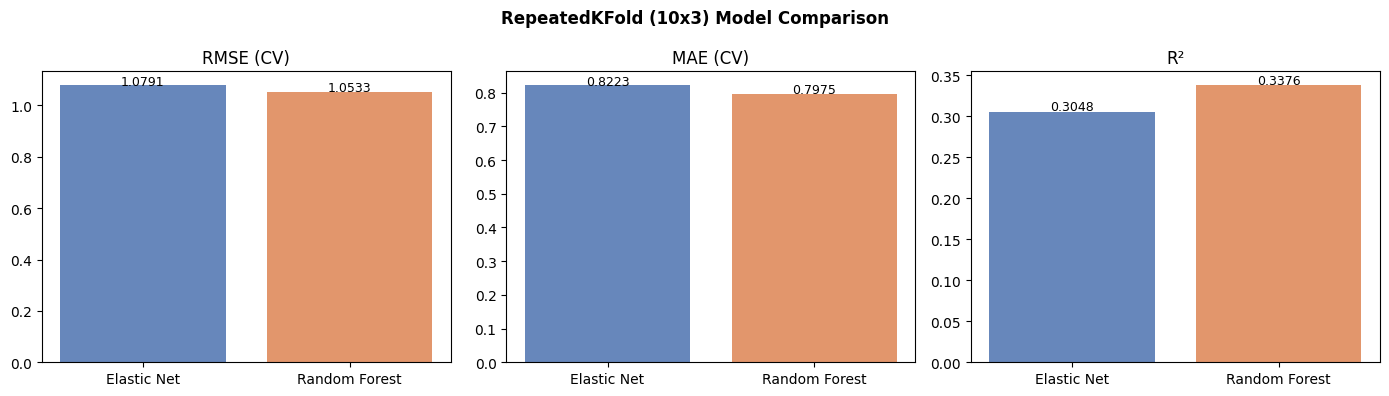

In [17]:
best_en.fit(X, y); best_rf.fit(X, y)

en_train = np.sqrt(mean_squared_error(y, best_en.predict(X)))
rf_train = np.sqrt(mean_squared_error(y, best_rf.predict(X)))
en_test  = np.sqrt(mean_squared_error(y_test, best_en.predict(X_test)))
rf_test  = np.sqrt(mean_squared_error(y_test, best_rf.predict(X_test)))

comp = pd.DataFrame({
    'Model':        ['Elastic Net', 'Random Forest'],
    'RMSE (CV)':    [en_rmse, rf_rmse],
    'RMSE (Test)':  [en_test, rf_test],
    'MAE (CV)':     [en_mae,  rf_mae],
    'R²':           [en_r2,   rf_r2],
}).set_index('Model').round(4)

print(comp.to_string())
print(f'\nEN  overfit gap: {en_rmse - en_train:+.4f}')
print(f'RF  overfit gap: {rf_rmse - rf_train:+.4f}')

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['RMSE (CV)', 'MAE (CV)', 'R²']):
    bars = ax.bar(comp.index, comp[col], color=['#4c72b0','#dd8452'], alpha=0.85)
    ax.set_title(col)
    for b, v in zip(bars, comp[col]):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002, f'{v:.4f}', ha='center', fontsize=9)
plt.suptitle('RepeatedKFold (10x3) Model Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

##  11. חשיבות פיצ'רים

=== EN — Top 5 ===
                Feature      Coef
      genre_Documentary  0.753716
           genre_Horror -0.547127
country_group_East_Asia  0.235904
       director_quality  0.219490
          actor_quality  0.188008

=== RF — Top 5 ===
         Feature  Importance  Direction
  genre_momentum    0.155919   0.168049
   actor_quality    0.145544   0.188008
director_quality    0.136831   0.219490
     log_runtime    0.094884   0.105877
  negative_count    0.067422  -0.051422

Top-5 overlap (EN ∩ RF): 2


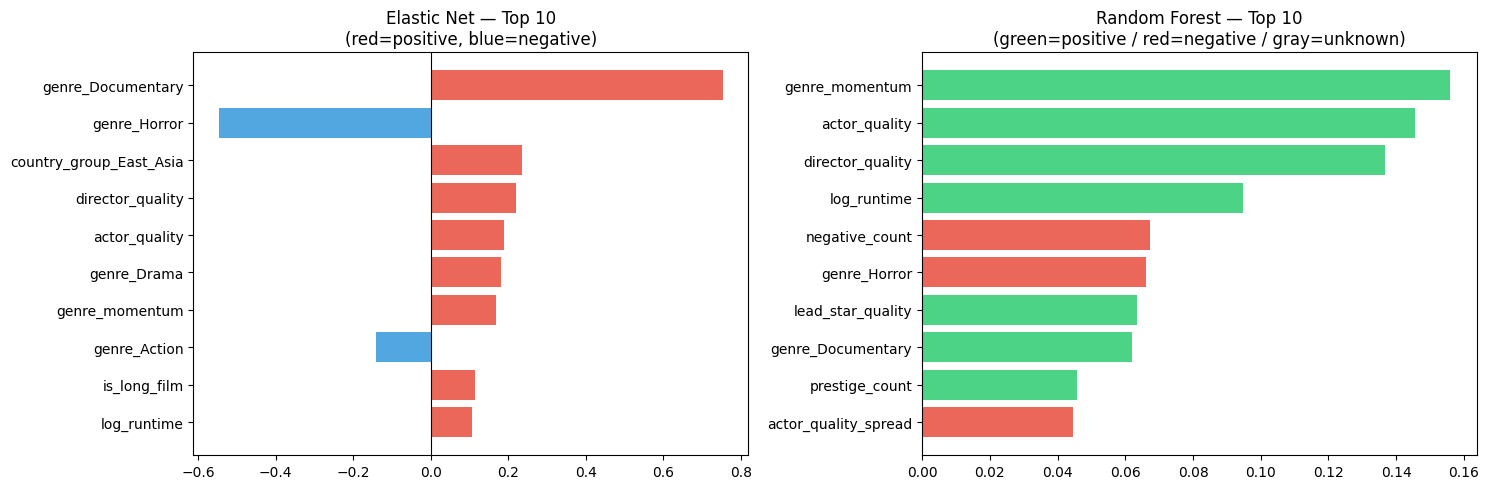

In [18]:
# שמות פיצ'רים אחרי OHE — סדר תואם את ColumnTransformer החדש
feat_names = (
    normal_num_cols +
    skewed_num_cols +
    BINARY_COLS +
    list(best_en.named_steps['prep']
         .named_transformers_['cat']
         .named_steps['ohe']
         .get_feature_names_out(CAT_COLS))
)

en_coefs = best_en.named_steps['model'].coef_
en_fi = pd.DataFrame({'Feature': feat_names[:len(en_coefs)],
                       'Coef': en_coefs, 'Abs': np.abs(en_coefs)})\
          .sort_values('Abs', ascending=False)

rf_imp = best_rf.named_steps['model'].feature_importances_
rf_fi  = pd.DataFrame({'Feature': feat_names[:len(rf_imp)], 'Importance': rf_imp})\
          .sort_values('Importance', ascending=False)

# Infer direction for RF from EN sign
en_sign = en_fi.set_index('Feature')['Coef'].reindex(rf_fi['Feature']).fillna(0)
rf_fi['Direction'] = en_sign.values

print('=== EN — Top 5 ===')
print(en_fi[['Feature','Coef']].head(5).to_string(index=False))
print('\n=== RF — Top 5 ===')
print(rf_fi[['Feature','Importance','Direction']].head(5).to_string(index=False))

print(f'\nTop-5 overlap (EN ∩ RF): {len(set(en_fi.head(5).Feature) & set(rf_fi.head(5).Feature))}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
top_en = en_fi.head(10)
axes[0].barh(top_en['Feature'][::-1], top_en['Coef'][::-1],
             color=['#e74c3c' if v>0 else '#3498db' for v in top_en['Coef'][::-1]], alpha=0.85)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Elastic Net — Top 10\n(red=positive, blue=negative)')
top_rf = rf_fi.head(10)
rf_colors = ['#2ecc71' if v>0.01 else '#e74c3c' if v<-0.01 else '#95a5a6' for v in top_rf['Direction']]
axes[1].barh(top_rf['Feature'][::-1], top_rf['Importance'][::-1], color=rf_colors[::-1], alpha=0.85)
axes[1].set_title('Random Forest — Top 10\n(green=positive / red=negative / gray=unknown)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()



##  12. Error Analysis

Out-of-Fold predictions עם `cross_val_predict` (5-fold) על Train — 10 Overpredictions + 10 Underpredictions.


In [19]:
kf5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

y_pred_rf = cross_val_predict(best_rf, X, y, cv=kf5, n_jobs=-1)
y_pred_en = cross_val_predict(best_en, X, y, cv=kf5, n_jobs=-1)

df_err = df_train[['tconst','primaryTitle','startYear','genres','averageRating']].copy()
df_err['pred_rf']  = y_pred_rf
df_err['pred_en']  = y_pred_en
df_err['error_rf'] = y_pred_rf - y
df_err['error_en'] = y_pred_en - y

print(f'RF OOF RMSE: {np.sqrt(mean_squared_error(y, y_pred_rf)):.4f}')
print(f'EN OOF RMSE: {np.sqrt(mean_squared_error(y, y_pred_en)):.4f}')

SHOW = ['primaryTitle','startYear','genres','averageRating','pred_rf','error_rf']
print('\n=== Top 10 Overpredictions ===')
print(df_err.nlargest(10, 'error_rf')[SHOW].to_string(index=False))
print('\n=== Top 10 Underpredictions ===')
print(df_err.nsmallest(10, 'error_rf')[SHOW].to_string(index=False))


RF OOF RMSE: 1.0539
EN OOF RMSE: 1.0791

=== Top 10 Overpredictions ===
                                     primaryTitle  startYear                       genres  averageRating  pred_rf  error_rf
                                             Kurz     2023.0                  Documentary            1.2 7.098288  5.898288
Brush with Life: The Art of Being Edward Biberman     2007.0              ['Documentary']            1.5 7.239919  5.739919
                 Obama in NC: The Path to History     2010.0              ['Documentary']            1.5 7.237075  5.737075
                                 Play in the Gray     2009.0 Biography,Comedy,Documentary            1.3 7.016311  5.716311
                                      Hatemongers     2000.0                  Documentary            1.6 7.230950  5.630950
                                    Amazing China     2018.0                  Documentary            1.8 7.320449  5.520449
                                  On BorrowedTime     2012.0

#1 [OVER] Kurz (2023)
  Genres: Documentary | Country: Unknown
  Actual: 1.2 → Pred: 7.10 (err: +5.90)
  Plot: nan

#2 [OVER] Brush with Life: The Art of Being Edward Biberman (2007)
  Genres: ['Documentary'] | Country: Unknown
  Actual: 1.5 → Pred: 7.24 (err: +5.74)
  Plot: nan

#3 [OVER] Obama in NC: The Path to History (2010)
  Genres: ['Documentary'] | Country: Unknown
  Actual: 1.5 → Pred: 7.24 (err: +5.74)
  Plot: nan

#4 [OVER] Play in the Gray (2009)
  Genres: Biography,Comedy,Documentary | Country: United States
  Actual: 1.3 → Pred: 7.02 (err: +5.72)
  Plot: An intimate look at identity, sexuality, love, and performance art, Play in the Gray, shakes the foundation of gender stereotypes by exploring the work and personal lives of Boston drag-based theatre troupe, ALL THE KINGS MEN

#5 [OVER] Hatemongers (2000)
  Genres: Documentary | Country: Unknown
  Actual: 1.6 → Pred: 7.23 (err: +5.63)
  Plot: nan

Over overlap  (RF∩EN): 9/10
Under overlap (RF∩EN): 6/10


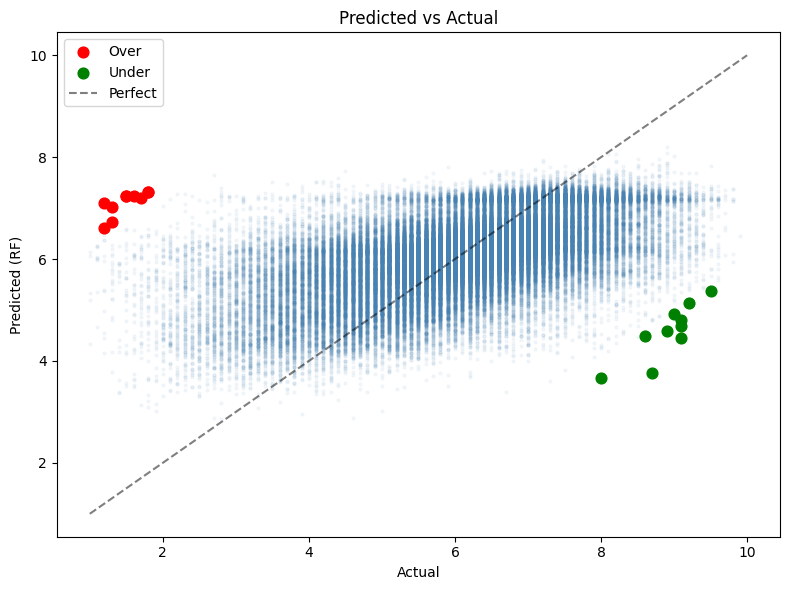

In [20]:
# ניתוח איכותי — Top 5 outliers
df_err['abs_rf'] = df_err['error_rf'].abs()
top5 = df_err.nlargest(5, 'abs_rf').merge(
    df_raw[['tconst','Country','runtimeMinutes','numVotes','plot']], on='tconst', how='left')

print('=' * 70)
for rank, row in enumerate(top5.itertuples(), 1):
    direction = 'OVER' if row.error_rf > 0 else 'UNDER'
    plot_text = str(row.plot)[:250]+'...' if pd.notna(row.plot) and len(str(row.plot))>250 else str(row.plot)
    print(f'#{rank} [{direction}] {row.primaryTitle} ({int(row.startYear) if pd.notna(row.startYear) else "?"})')
    print(f'  Genres: {row.genres} | Country: {row.Country if pd.notna(row.Country) else "Unknown"}')
    print(f'  Actual: {row.averageRating:.1f} → Pred: {row.pred_rf:.2f} (err: {row.error_rf:+.2f})')
    print(f'  Plot: {plot_text}')
    print()

# השוואה בין מודלים
over_rf  = set(df_err.nlargest(10,'error_rf')['primaryTitle'])
over_en  = set(df_err.nlargest(10,'error_en')['primaryTitle'])
under_rf = set(df_err.nsmallest(10,'error_rf')['primaryTitle'])
under_en = set(df_err.nsmallest(10,'error_en')['primaryTitle'])
print(f'Over overlap  (RF∩EN): {len(over_rf & over_en)}/10')
print(f'Under overlap (RF∩EN): {len(under_rf & under_en)}/10')

# Scatter
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y, y_pred_rf, alpha=0.05, s=5, color='steelblue')
over_idx  = df_err.nlargest(10,'error_rf').index
under_idx = df_err.nsmallest(10,'error_rf').index
ax.scatter(y[over_idx],  y_pred_rf[over_idx],  color='red',   s=60, label='Over',  zorder=5)
ax.scatter(y[under_idx], y_pred_rf[under_idx], color='green', s=60, label='Under', zorder=5)
ax.plot([1,10],[1,10],'k--',alpha=0.5,label='Perfect')
ax.set(xlabel='Actual', ylabel='Predicted (RF)', title='Predicted vs Actual')
ax.legend(); plt.tight_layout()
plt.savefig('error_scatter.png', dpi=100); plt.show()


##  13. Fairness Analysis

             Slice     N   RMSE    MAE  %_above
           Overall 23112 1.0227 0.7757      0.0
      Genre: Drama 11726 0.9627 0.7295     -5.9
     Genre: Action  2877 1.1005 0.8487      7.6
Genre: Documentary  2614 0.9795 0.7092     -4.2
   Genre: Thriller  2368 1.0884 0.8424      6.4
     Genre: Horror  2002 1.1111 0.8769      8.6
       Country: US  4206 0.8870 0.6684    -13.3
Country: East_Asia   730 0.7614 0.5700    -25.6
    Country: Other 18176 1.0605 0.8088      3.7


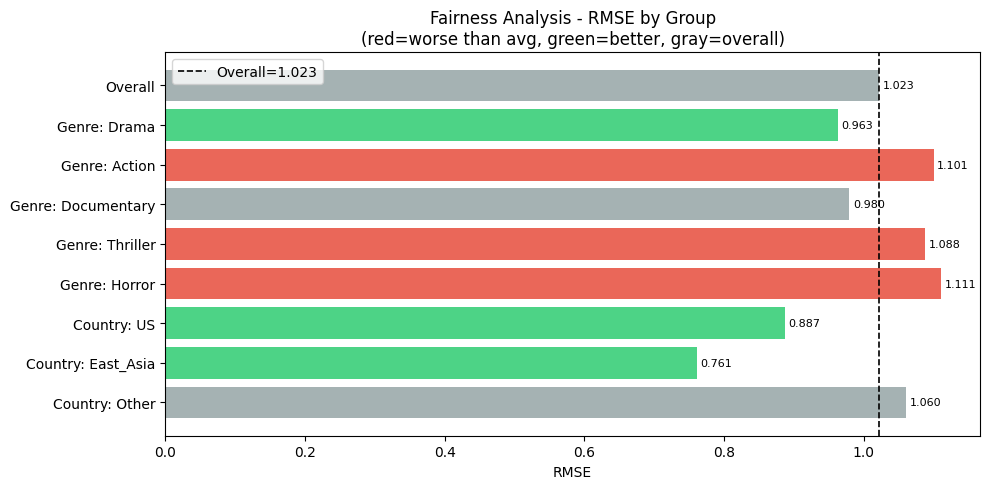

In [21]:
df_fair = df_test.copy()
X_fair  = prepare_data(df_fair)
for col in ALL_GENRES:
    df_fair[f'genre_{col}'] = X_fair[f'genre_{col}'].values
df_fair['country_group'] = X_fair['country_group'].values
df_fair['y_pred'] = best_rf.predict(X_test)
df_fair['y_true'] = y_test

def slice_metrics(mask, label):
    sub = df_fair[mask]
    if len(sub) < 50: return None
    return {'Slice': label, 'N': len(sub),
            'RMSE': round(np.sqrt(mean_squared_error(sub['y_true'],sub['y_pred'])),4),
            'MAE':  round(mean_absolute_error(sub['y_true'],sub['y_pred']),4)}

rows = [slice_metrics(np.ones(len(df_fair),dtype=bool), 'Overall')]

for g in ['Drama', 'Action', 'Documentary', 'Thriller', 'Horror']:
    r = slice_metrics(df_fair[f'genre_{g}']==1, f'Genre: {g}')
    if r: rows.append(r)

for grp in ['US','East_Asia','Other']:
    r = slice_metrics(df_fair['country_group']==grp, f'Country: {grp}')
    if r: rows.append(r)

fairness_df = pd.DataFrame([r for r in rows if r])
overall = fairness_df.loc[fairness_df['Slice']=='Overall','RMSE'].values[0]
fairness_df['%_above'] = ((fairness_df['RMSE']/overall - 1)*100).round(1)
print(fairness_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
rmse_vals = fairness_df['RMSE'].tolist()
slices    = fairness_df['Slice'].tolist()
colors = ['#e74c3c' if r>overall*1.05 else '#2ecc71' if r<overall*0.95 else '#95a5a6' for r in rmse_vals]
bars = ax.barh(slices[::-1], rmse_vals[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(overall, color='black', ls='--', lw=1.2, label=f'Overall={overall:.3f}')
for bar, val in zip(bars, rmse_vals[::-1]):
    ax.text(val+0.005, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)
ax.set_xlabel('RMSE')
ax.set_title('Fairness Analysis - RMSE by Group\n(red=worse than avg, green=better, gray=overall)')
ax.legend(); plt.tight_layout()
plt.savefig('fairness_analysis.png', dpi=100); plt.show()

##  14. שמירת המודל

In [22]:
best_model      = best_rf if rf_test <= en_test else best_en
best_model_name = 'Random Forest' if rf_test <= en_test else 'Elastic Net'
print(f'Best model: {best_model_name}')
print(f'EN  → CV={en_rmse:.4f} Test={en_test:.4f} Adj.R²={en_adj:.4f}')
print(f'RF  → CV={rf_rmse:.4f} Test={rf_test:.4f} Adj.R²={rf_adj:.4f}')

# Re-fit על כל הנתונים
X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all = np.concatenate([y_train, y_test])
best_model.fit(X_all, y_all)

# Final metrics
final_r2  = r2_score(y_test, best_rf.predict(X_test))
final_adj = adjusted_r2(final_r2, len(y_test), N_FEATURES)
print(f'\nTest RMSE={rf_test:.4f} | MAE={mean_absolute_error(y_test,best_rf.predict(X_test)):.4f} | Adj.R²={final_adj:.4f}')

joblib.dump(best_model, 'model.pkl')
joblib.dump({'actor_quality_map': ACTOR_QUALITY_MAP,
             'global_mean_rating': GLOBAL_MEAN_RATING}, 'actor_quality.pkl')
print('Saved: model.pkl | actor_quality.pkl')

loaded = joblib.load('model.pkl')
preds  = loaded.predict(X_test.iloc[:3])
for i,(p,a) in enumerate(zip(preds, y_test[:3])):
    print(f'  Sample {i+1}: pred={p:.2f} actual={a:.2f}')


Best model: Random Forest
EN  → CV=1.0791 Test=1.0433 Adj.R²=0.3046
RF  → CV=1.0533 Test=1.0227 Adj.R²=0.3375

Test RMSE=1.0227 | MAE=0.6713 | Adj.R²=0.5116
Saved: model.pkl | actor_quality.pkl
  Sample 1: pred=5.14 actual=5.10
  Sample 2: pred=5.35 actual=3.50
  Sample 3: pred=6.54 actual=7.20
